In [36]:
# ==============================================================================
# CELL 1: DEVELOPMENT UTILITIES & ENVIRONMENT ALIGNMENT
# ==============================================================================
# 1. Enable automatic reloading of modified local scripts
%load_ext autoreload
%autoreload 2

import sys
import os

# This bridges the notebook to the custom /src modules
sys.path.append(os.path.abspath('.'))

print("🚀 Environment aligned! Notebook is linked to your /src architecture.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 Environment aligned! Notebook is linked to your /src architecture.


## Part 1: Data Ingestion & Local Storage Setup

In this section, we programmatically pull two localized datasets from Kaggle containing Philippine-context SMS spam and smishing messages:
1. `bwandowando/philippine-spam-sms-messages`
2. `scottleechua/ph-spam-marketing-sms-w-timestamps`

We leverage `kagglehub` to handle API communication. Our backend script copies these files out of the system cache into our tracking repository (`data/1_raw/`), normalizes their conflicting schemas, strips cross-over duplicate texts, and converts string classes into strict integers ($0$ for Ham, $1$ for Smishing/Spam) inside `data/2_interim/`.

In [37]:
from src.loaders.data_loader import load_and_combine_ph_data

# Triggers the automated extraction from the Kaggle Cache Matrix
df_raw = load_and_combine_ph_data()

# Render descriptive outputs directly in your log dashboard
print("\n--- Remaining Targets for Machine Learning Evaluation ---")
print(df_raw['category'].value_counts())

📥 Loading Dataset 1 (bwandowando)...
📥 Loading Dataset 2 (scottleechua)...
🏁 Data Ingestion Complete! Merged shape: (2731, 6)

--- Remaining Targets for Machine Learning Evaluation ---
category
smishing    1843
ads          752
gov          133
notifs         3
Name: count, dtype: int64


In [38]:
from src.preprocessing.text_cleaner import SmishingFeatureExtractor

extractor = SmishingFeatureExtractor()
df_features = extractor.extract_meta_features(df_raw)

print("✅ Meta-features appended successfully!")
df_features[['text', 'text_len', 'has_url',
             'urgency_score', 'hour_received', 'label']].head()

✅ Meta-features appended successfully!


,text,text_len,has_url,urgency_score,hour_received,label
137,Nice! You received a P10 voucher from Maya. Us...,156,0,1,18,0
138,Nice! You received a P20 voucher from Maya. Us...,156,0,1,11,0
139,Nice! You received a P10 voucher from Maya. Us...,156,0,1,16,0
140,Nice! You received a P20 voucher from Maya. Us...,156,0,1,12,0
141,Nice! You received a P10 voucher from Maya. Us...,156,0,1,13,0


## Part 4: Feature Matrix Partitioning & Vectorization
We isolate our engineered numerical features from raw target flags ($y$). To ensure our text metrics remain untainted by validation data leakage, we partition our data arrays into training and evaluation blocks *before* extracting our text TF-IDF tokens.

In [39]:
# ==============================================================================
# CELL 7: FEATURE EXTRACTION & SPLITTING
# ==============================================================================
from sklearn.model_selection import train_test_split
from src.preprocessing.vectorizers import SmishingTfidfVectorizer

# 1. Isolate target variable y from your features dataframe
y = df_features['label']

# 2. Build metadata feature list from df_features
meta_columns = ["text_len", "has_url", "urgency_score", "hour_received"] + \
    [col for col in df_features.columns if col.startswith("sc_")]
X_meta = df_features[meta_columns].values
X_text_raw = df_features["text"]

# 3. Stratified Split to preserve exact class imbalances
X_text_train_raw, X_text_test_raw, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_text_raw, X_meta, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Initialize and run our modular Vectorizer Layer
tfidf_handler = SmishingTfidfVectorizer(max_features=10000)
X_text_train = tfidf_handler.fit_transform(X_text_train_raw)
X_text_test = tfidf_handler.transform(X_text_test_raw)

# Save the matrix state for potential final Streamlit production integration
tfidf_handler.save_vectorizer()

print("\n--- Feature Matrix Dimensionality Verification ---")
print(
    f"X_text_train Shape: {X_text_train.shape} | X_meta_train Shape: {X_meta_train.shape}")
print(
    f"X_text_test Shape:  {X_text_test.shape}  | X_meta_test Shape:  {X_meta_test.shape}")

📦 TF-IDF Vectorizer saved to saved_models/tfidf_vectorizer.pkl

--- Feature Matrix Dimensionality Verification ---
X_text_train Shape: (2184, 10000) | X_meta_train Shape: (2184, 7)
X_text_test Shape:  (547, 10000)  | X_meta_test Shape:  (547, 7)


--- Individual Model Performance ---
✅ SVM (Text): Complete
✅ Naive Bayes (Text): Complete
✅ Logistic Regression (Text): Complete
✅ Random Forest (Metadata): Complete
✅ XGBoost (Metadata Base): Complete


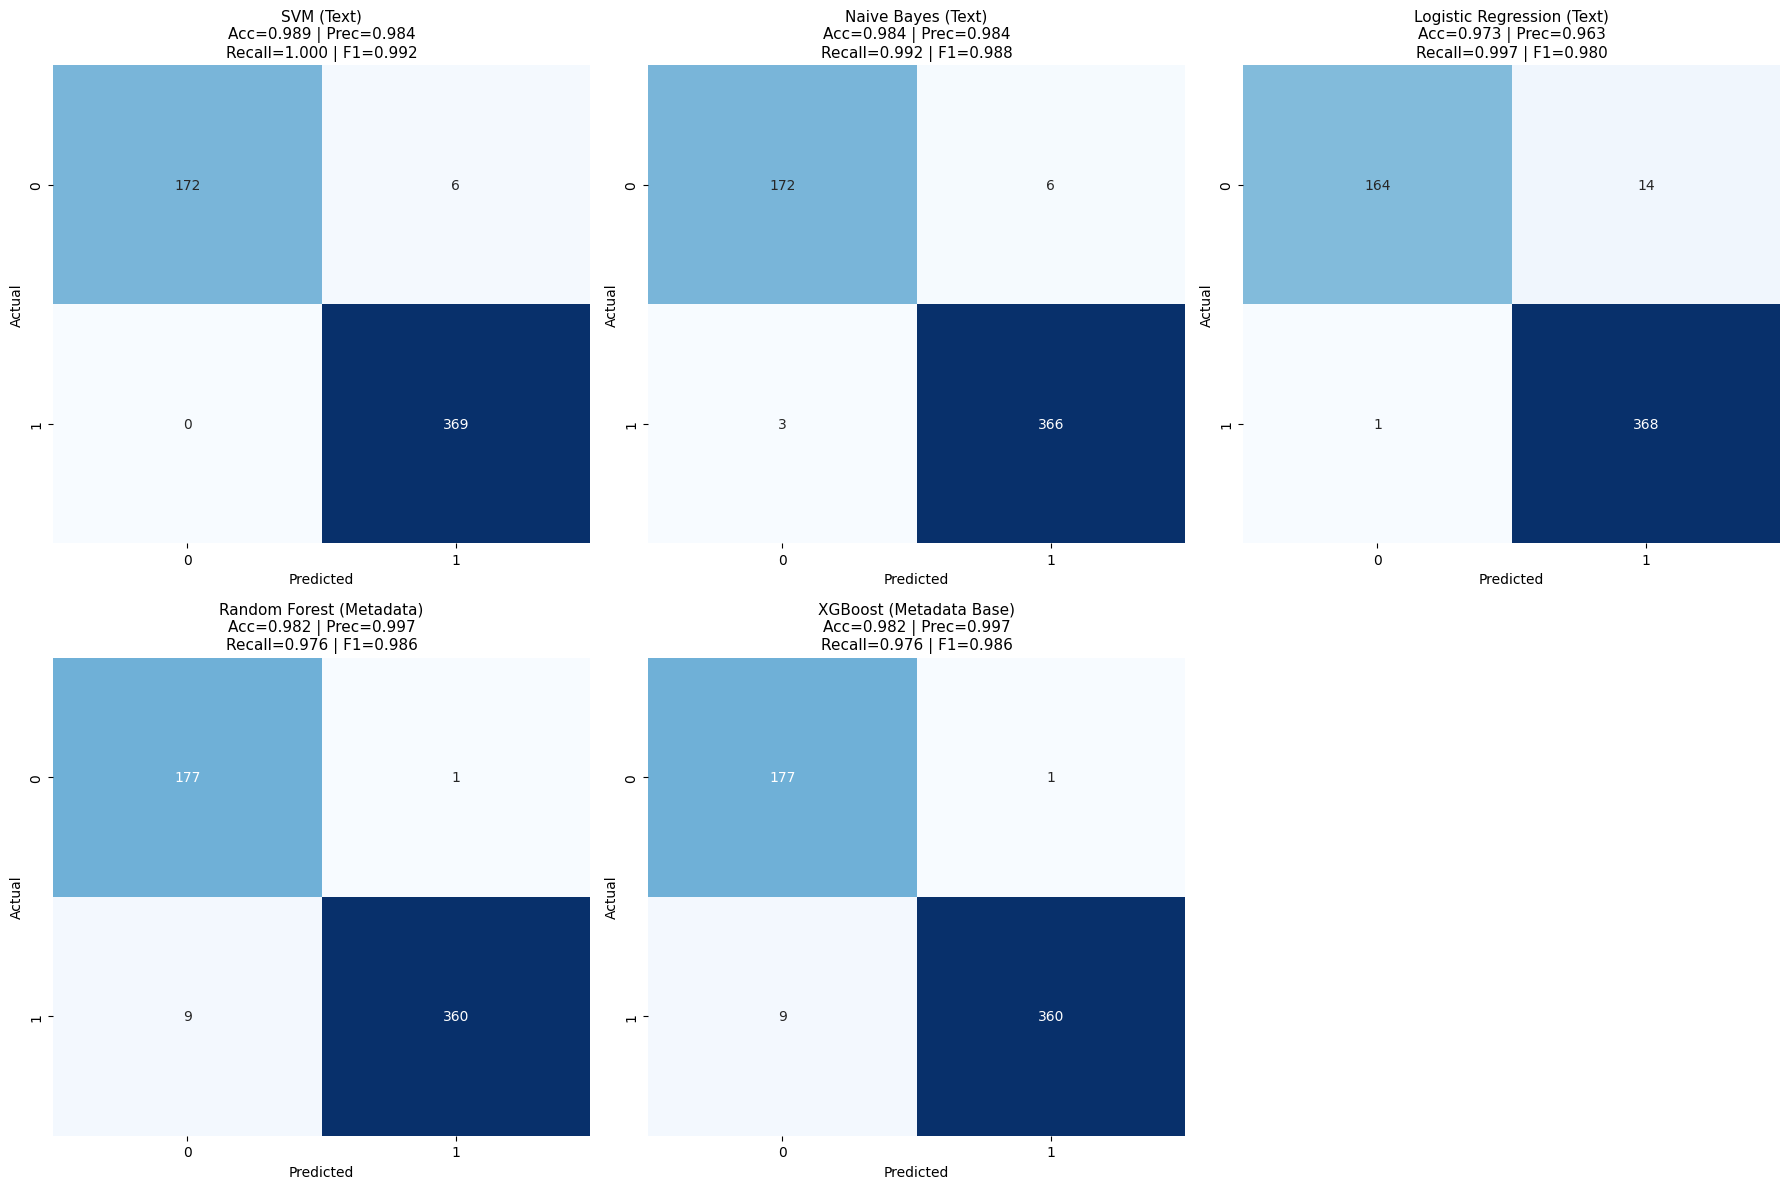


--- Final Model Performance Summary Table ---


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM (Text),0.989031,0.984000,1.00000,0.991935
1,Naive Bayes (Text),0.983547,0.983871,0.99187,0.987854
2,Random Forest (Metadata),0.981718,0.997230,0.97561,0.986301
3,XGBoost (Metadata Base),0.981718,0.997230,0.97561,0.986301
4,Logistic Regression (Text),0.972578,0.963351,0.99729,0.980027


In [40]:
# ==============================================================================
# CELL 8: ENSEMBLE EVALUATION & HEATMAP GRAPHING
# ==============================================================================
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from src.evaluation.metrics import evaluate_and_plot_models

# Define your algorithm architecture dictionaries mapping to their respective inputs
models_config = {
    "SVM (Text)": (SVC(kernel="linear", random_state=42), X_text_train, X_text_test),
    "Naive Bayes (Text)": (MultinomialNB(), X_text_train, X_text_test),
    "Logistic Regression (Text)": (LogisticRegression(max_iter=1000, random_state=42), X_text_train, X_text_test),
    "Random Forest (Metadata)": (RandomForestClassifier(n_estimators=100, random_state=42), X_meta_train, X_meta_test),
    "XGBoost (Metadata Base)": (XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42), X_meta_train, X_meta_test),
}

# Run the training loops, metric generation, and plotting backend
results_df = evaluate_and_plot_models(models_config, y_train, y_test)

print("\n--- Final Model Performance Summary Table ---")
results_df

## Part 5: Stacking & Meta-Feature Optimization
To extract maximal defense efficiency, we employ a **Stacked Ensemble** approach. We use text-specific probabilities (from SVM, NB, LR) alongside structural meta-feature models (RF, XGB) to train a top-tier **XGBoost Meta-Classifier**. 

To prevent data leakage into our second-layer model, we execute a 5-fold `cross_val_predict` routine across the base estimators. We then iterate through all 31 non-empty mathematical sub-combinations to discover our champion defense architecture.

In [42]:
# ==============================================================================
# CELL 10: STACKED ENSEMBLE COMBINATION ANALYSIS
# ==============================================================================
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from src.models.ensemble import evaluate_all_stacked_combinations

# 1. Map models to their corresponding inputs (Text or Metadata)
base_models_config = {
    "SVM": (SVC(kernel="linear", probability=True, random_state=42), X_text_train, X_text_test),
    "LR": (LogisticRegression(max_iter=1000, random_state=42), X_text_train, X_text_test),
    "NB": (MultinomialNB(), X_text_train, X_text_test),
    "RF": (RandomForestClassifier(n_estimators=100, random_state=42), X_meta_train, X_meta_test),
    "XGB_Base": (XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42), X_meta_train, X_meta_test)
}

# 2. Fire up the backend modular search engine (UNPACKING ALL 3 OUTPUTS)
stacked_results_df, train_probs, test_probs = evaluate_all_stacked_combinations(
    base_models_config, y_train, y_test
)

# 3. Output the ultimate Top 10 configurations for grading
print("\n🏆 --- Top 10 Stacked Ensemble Combinations --- 🏆")
stacked_results_df.head(10)

🔄 Generating out-of-fold base model probabilities...
  ↳ SVM: Probabilities generated.
  ↳ LR: Probabilities generated.
  ↳ NB: Probabilities generated.
  ↳ RF: Probabilities generated.
  ↳ XGB_Base: Probabilities generated.

⚔️ Evaluating all 31 stacked ensemble combinations...

🎉 All combinations evaluated successfully!

🏆 --- Top 10 Stacked Ensemble Combinations --- 🏆


,Combination,Model_Count,Accuracy,Precision,Recall,F1-Score
0,SVM + NB + RF + XGB_Base,4,0.992687,0.997275,0.99187,0.994565
1,SVM + LR + XGB_Base,3,0.990859,0.994565,0.99187,0.993216
2,SVM + LR + RF + XGB_Base,4,0.990859,0.994565,0.99187,0.993216
3,SVM + NB + XGB_Base,3,0.990859,0.997268,0.98916,0.993197
4,SVM + RF + XGB_Base,3,0.990859,0.997268,0.98916,0.993197
5,SVM + LR + NB + XGB_Base,4,0.990859,0.997268,0.98916,0.993197
6,SVM + LR + NB + RF + XGB_Base,5,0.990859,0.997268,0.98916,0.993197
7,SVM + LR + NB,3,0.989031,0.989218,0.99458,0.991892
8,SVM + LR,2,0.989031,0.989218,0.99458,0.991892
9,SVM + XGB_Base,2,0.989031,0.991870,0.99187,0.991870


C:\Users\joshu\AppData\Local\Temp\ipykernel_77480\2809722070.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


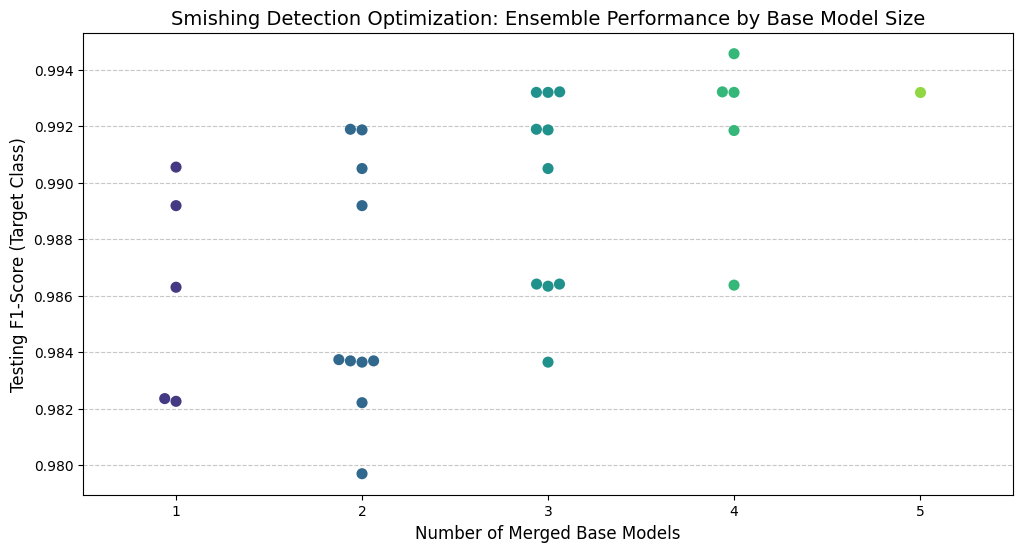

🥇 THE WINNING SYSTEM ARCHITECTURE: SVM + NB + RF + XGB_Base
🔥 Champion F1-Score: 0.9946


In [43]:
# ==============================================================================
# CELL 11: ENSEMBLE PERFORMANCE LANDSCAPE VISUALIZATION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Plot the F1-Score of all combinations colored by the number of models involved
sns.swarmplot(
    data=stacked_results_df,
    x="Model_Count",
    y="F1-Score",
    palette="viridis",
    size=8
)

plt.title("Smishing Detection Optimization: Ensemble Performance by Base Model Size", fontsize=14)
plt.xlabel("Number of Merged Base Models", fontsize=12)
plt.ylabel("Testing F1-Score (Target Class)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Extract and crown the master configuration
champion_combo = stacked_results_df.iloc[0]
print(f"🥇 THE WINNING SYSTEM ARCHITECTURE: {champion_combo['Combination']}")
print(f"🔥 Champion F1-Score: {champion_combo['F1-Score']:.4f}")

🔄 Generating out-of-fold base model probabilities...
  ↳ SVM: Probabilities generated.
  ↳ LR: Probabilities generated.
  ↳ NB: Probabilities generated.
  ↳ RF: Probabilities generated.
  ↳ XGB_Base: Probabilities generated.

⚔️ Evaluating all 31 stacked ensemble combinations...

🎉 All combinations evaluated successfully!
🔮 Generating all 31 hybrid ensemble confusion matrices (Purples Spectrum)...


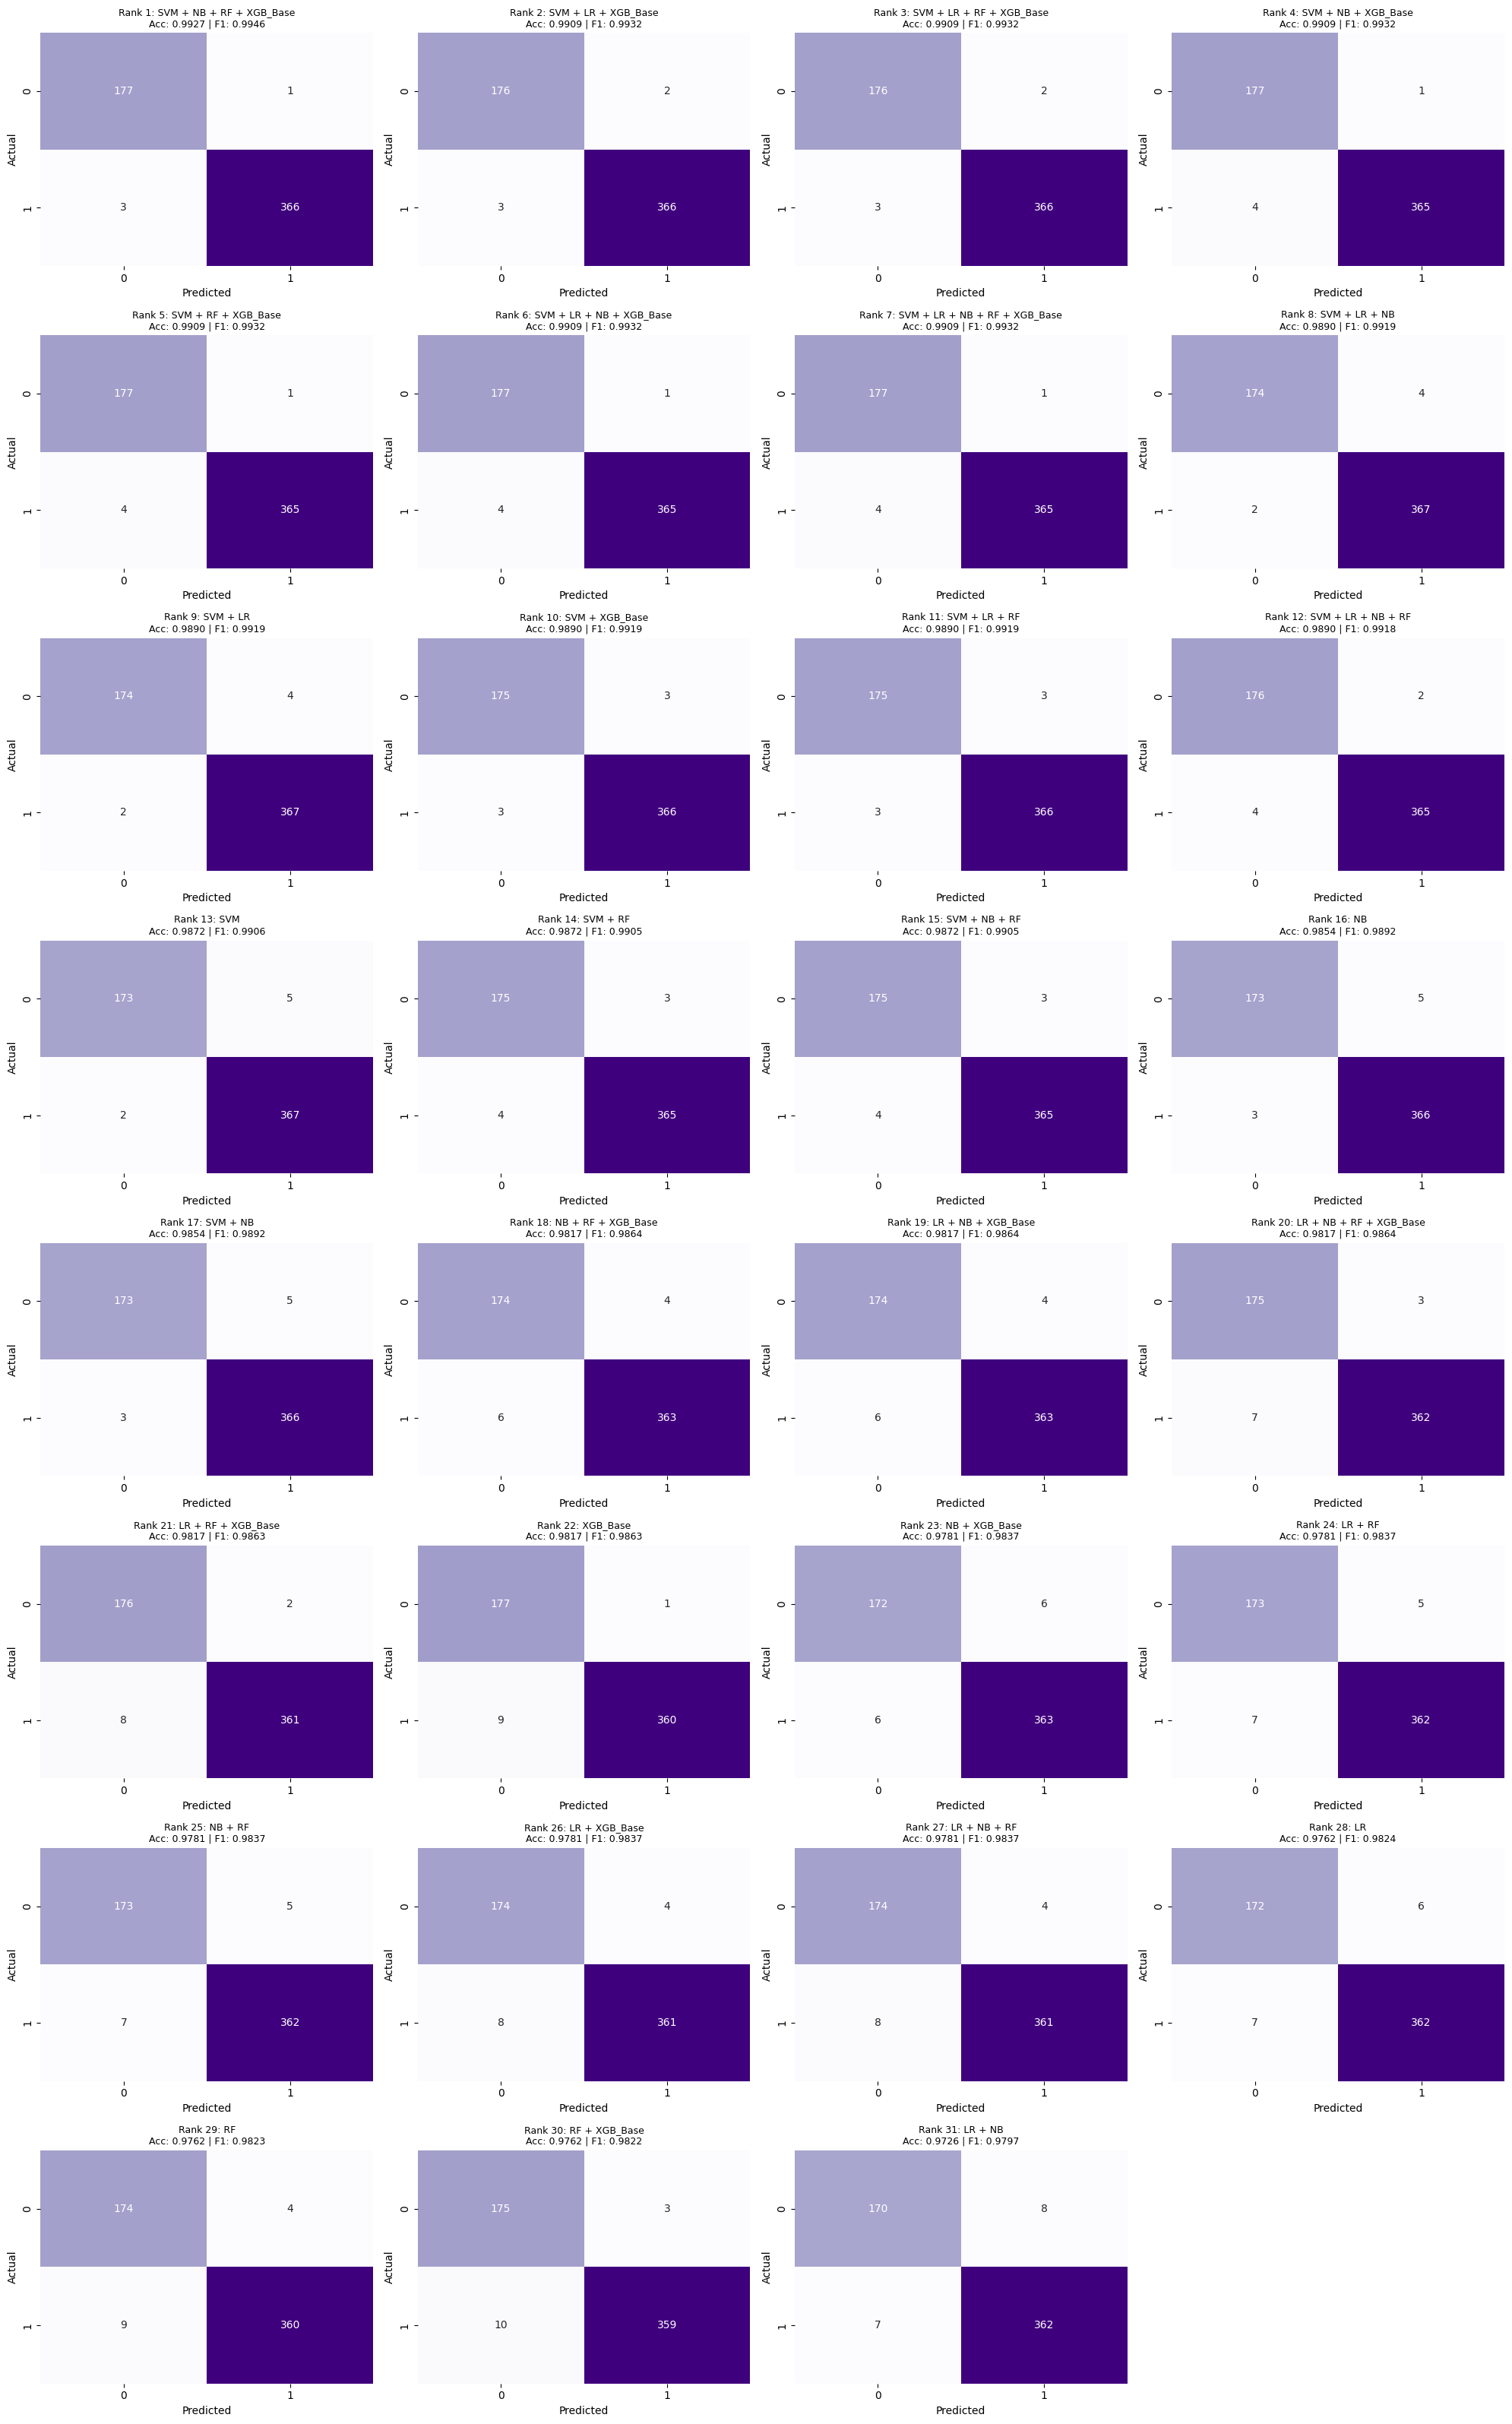

In [44]:
# ==============================================================================
# CELL 11: GRAND FINALE - ALL 31 ENSEMBLE CONFUSION MATRICES
# ==============================================================================
from src.evaluation.metrics import plot_all_ensemble_matrices

# 1. Re-run the ensemble with our new tuple-return setup
stacked_results_df, train_probs, test_probs = evaluate_all_stacked_combinations(
    base_models_config, y_train, y_test
)

# 2. Render the giant master evaluation grid layout
plot_all_ensemble_matrices(
    stacked_results_df, train_probs, test_probs, y_train, y_test)

In [45]:
# ==============================================================================
# CELL 12: ARTIFACT EXPORTATION (PICKLING THE CHAMPION)
# ==============================================================================
from src.models.ensemble import train_and_save_champion

# Train the absolute winner on your out-of-fold states and pickle it
winning_base_models = train_and_save_champion(
    stacked_results_df, train_probs, test_probs, y_train
)

print("\n🚀 Production pipeline artifacts successfully exported and secured!")
print(
    f"To deploy, the web application will need to load: {winning_base_models}")


🏆 Champion Combination Identified: SVM + NB + RF + XGB_Base
🥇 Validation F1-Score: 0.9946
🏋️ Freezing final meta-classifier parameters...
📦 Success! Champion ensemble model pickled directly to: saved_models/champion_ensemble.pkl

🚀 Production pipeline artifacts successfully exported and secured!
To deploy, the web application will need to load: ['SVM', 'NB', 'RF', 'XGB_Base']


In [ ]:
# ==============================================================================
# CELL 12: TRAIN CHAMPION ENSEMBLE AND EXPORT ALL PRODUCTION MODELS
# ==============================================================================
import joblib
import os
import numpy as np
from xgboost import XGBClassifier

# 1. Ensure the export folder exists
os.makedirs("saved_models", exist_ok=True)

# 2. Extract the absolute highest-performing combination from your results table
champion_row = stacked_results_df.iloc[0]
champion_combo_name = champion_row["Combination"]
best_combo = champion_combo_name.split(" + ")

print(
    f"🥇 Automatically identified champion combination: {champion_combo_name}")
print(f"📈 Top F1-Score: {champion_row['F1-Score']:.4f}")

# 3. Re-stack the exact subset of out-of-fold training probabilities that won
meta_X_train_best = np.column_stack([
    train_probs[m] for m in best_combo
])

# 4. Instantiate and fit your missing production meta-classifier variable
print("🏋️ Training production meta-classifier...")
best_meta_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
best_meta_model.fit(meta_X_train_best, y_train)

# 5. Export the 5 fitted base models from your notebook dictionary
print("📦 Pickling base models...")
joblib.dump(base_models_config["SVM"][0], "saved_models/base_svm.pkl")
joblib.dump(base_models_config["LR"][0], "saved_models/base_lr.pkl")
joblib.dump(base_models_config["NB"][0], "saved_models/base_nb.pkl")
joblib.dump(base_models_config["RF"][0], "saved_models/base_rf.pkl")
joblib.dump(base_models_config["XGB_Base"][0], "saved_models/base_xgb.pkl")

# 6. Export the newly created champion meta-classifier
joblib.dump(best_meta_model, "saved_models/champion_ensemble.pkl")

print("\n🎉 SUCCESS! All 5 base models and your champion meta-classifier are secured in 'saved_models/'!")

🥇 Automatically identified champion combination: SVM + NB + RF + XGB_Base
📈 Top F1-Score: 0.9946
🏋️ Training production meta-classifier...
📦 Pickling base models...

🎉 SUCCESS! All 5 base models and your champion meta-classifier are secured in 'saved_models/'!


In [53]:
print(list(X_train_meta_df.columns))

NameError: name 'X_train_meta_df' is not defined